In [ ]:
import pandas as pd
import time

# Pastikan nama file ini sesuai dengan dataset 6GB Anda yang ada di folder Skripsi_FDI
# file_path = 'NF-ToN-IoT-v3.csv' 
file_path = 'datasets/dataset_final_2juta.csv' 

print("Mulai membaca 1000 baris pertama...")
waktu_mulai = time.time()

# Kita batasi 1000 baris dan gunakan engine C agar secepat kilat
df_sample = pd.read_csv(file_path, nrows=1000, engine='c')

waktu_selesai = time.time()
print(f"✅ Selesai dalam {waktu_selesai - waktu_mulai:.2f} detik!")
print(f"Ukuran sampel: {df_sample.shape[0]} baris, {df_sample.shape[1]} kolom.")

# Tampilkan 5 baris pertama
display(df_sample.head())

Mulai membaca 1000 baris pertama...
✅ Selesai dalam 0.02 detik!
Ukuran sampel: 1000 baris, 50 kolom.


,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,...,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label
0,50634,4485,6,0,48,1,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0
1,41711,10824,6,0,48,1,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0
2,11024,4598,6,0,48,1,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0
3,51307,10937,6,0,48,1,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0
4,54214,4711,6,0,48,1,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0


In [2]:
# 1. Mengecek nama kolom target (biasanya bernama 'Label' atau 'Attack')
print("Daftar 5 Kolom Terakhir (untuk mencari kolom Target/Label):")
print(df_sample.columns[-5:].tolist())
print("-" * 50)

# 2. Mengecek apakah ada nilai kosong (NaN) di dalam sampel
jumlah_nan = df_sample.isna().sum().sum()
print(f"Jumlah total nilai kosong (NaN) di sampel ini: {jumlah_nan}")

# 3. Mengecek tipe data untuk memastikan semuanya numerik (syarat masuk model)
tipe_non_numerik = df_sample.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
print(f"Kolom dengan tipe data non-numerik (teks/kategori): {tipe_non_numerik}")

Daftar 5 Kolom Terakhir (untuk mencari kolom Target/Label):
['DST_TO_SRC_IAT_MAX', 'DST_TO_SRC_IAT_AVG', 'DST_TO_SRC_IAT_STDDEV', 'Label', 'Attack']
--------------------------------------------------
Jumlah total nilai kosong (NaN) di sampel ini: 0
Kolom dengan tipe data non-numerik (teks/kategori): ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Attack']


In [3]:
# Mari kita lihat daftar lengkap isi kolom 'Attack' di sampel ini
print("Daftar jenis kelas (Normal & Serangan) beserta jumlahnya:")
print(df_sample['Attack'].value_counts())

Daftar jenis kelas (Normal & Serangan) beserta jumlahnya:
Attack
Benign      967
scanning     33
Name: count, dtype: int64


In [4]:
file_path = 'NF-ToN-IoT-v3.csv' # Jangan lupa sesuaikan namanya

unique_attacks = set()
print("Sedang memindai seluruh file 6 GB secara bertahap (chunking)...")
print("Ini mungkin memakan waktu 1-3 menit, silakan ditunggu.")

# Kita hanya memuat kolom 'Attack' saja agar sangat ringan dan cepat
for chunk in pd.read_csv(file_path, chunksize=500000, usecols=['Attack'], engine='c'):
    # Tambahkan jenis serangan yang baru ditemukan ke dalam himpunan (set)
    unique_attacks.update(chunk['Attack'].dropna().unique())

print("\n✅ Pemindaian Selesai!")
print("Daftar LENGKAP semua jenis kelas/serangan di dataset ini:")
for attack in unique_attacks:
    print(f"- {attack}")

Sedang memindai seluruh file 6 GB secara bertahap (chunking)...
Ini mungkin memakan waktu 1-3 menit, silakan ditunggu.

✅ Pemindaian Selesai!
Daftar LENGKAP semua jenis kelas/serangan di dataset ini:
- password
- xss
- scanning
- mitm
- Backdoor
- injection
- ddos
- Benign
- ransomware
- dos


In [5]:
# Nama file 6 GB Anda (sesuaikan jika berbeda)
file_path = 'NF-ToN-IoT-v3.csv' 
# Nama file BARU yang akan jauh lebih kecil dan ringan
new_file_path = 'dataset_fdi_bersih.csv' 

# Kolom teks/kategori yang sepakat kita buang agar algoritma bisa belajar dengan baik
kolom_dibuang = ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Attack']

print("Memulai proses penyaringan khusus kelas 'Benign' dan 'injection'...")
print("Sedang memproses dan membuat file baru (harap tunggu 1-3 menit)...")

header_ditulis = False
total_baris_tersimpan = 0

# Kita baca lagi 6 GB sepotong-sepotong agar RAM tetap aman
for chunk in pd.read_csv(file_path, chunksize=500000, engine='c'):
    
    # 1. Filter: Ambil hanya baris yang Attack-nya 'Benign' atau 'injection'
    chunk_filtered = chunk[chunk['Attack'].isin(['Benign', 'injection'])].copy()
    
    # Jika di potongan ini ada datanya, kita proses dan simpan
    if not chunk_filtered.empty:
        # 2. Buang kolom IP dan Attack (karena kita akan pakai kolom 'Label' 0/1 untuk targetnya)
        chunk_filtered = chunk_filtered.drop(columns=kolom_dibuang, errors='ignore')
        
        # 3. Simpan langsung ke file CSV baru
        if not header_ditulis:
            # Tulis file baru beserta nama kolomnya (header)
            chunk_filtered.to_csv(new_file_path, index=False, mode='w')
            header_ditulis = True
        else:
            # Tambahkan (append) ke baris bawahnya tanpa menulis nama kolom lagi
            chunk_filtered.to_csv(new_file_path, index=False, mode='a', header=False)
            
        total_baris_tersimpan += len(chunk_filtered)

print(f"\n✅ BINGO! Dataset skripsi berhasil dibuat: {new_file_path}")
print(f"Total data Anda sekarang mengerucut menjadi: {total_baris_tersimpan} baris.")

Memulai proses penyaringan khusus kelas 'Benign' dan 'injection'...
Sedang memproses dan membuat file baru (harap tunggu 1-3 menit)...

✅ BINGO! Dataset skripsi berhasil dibuat: dataset_fdi_bersih.csv
Total data Anda sekarang mengerucut menjadi: 17173991 baris.


In [6]:
new_file_path = 'dataset_fdi_bersih.csv'
print("Mengecek proporsi data Normal (0) vs Injection (1)...")

# Kita siapkan wadah kosong untuk menghitung
distribusi = pd.Series(dtype=int)

# Kita baca lagi pakai chunking agar RAM tetap aman
for chunk in pd.read_csv(new_file_path, chunksize=1000000, usecols=['Label'], engine='c'):
    # Tambahkan jumlah 0 dan 1 dari setiap potongan data
    distribusi = distribusi.add(chunk['Label'].value_counts(), fill_value=0)

print("\n✅ Hasil Distribusi Kelas pada Dataset Skripsi Anda:")
print(distribusi.astype(int))
print("-" * 50)
persentase_serangan = (distribusi.get(1, 0) / distribusi.sum()) * 100
print(f"Persentase Serangan Injection: {persentase_serangan:.2f}% dari total lalu lintas jaringan.")

Mengecek proporsi data Normal (0) vs Injection (1)...

✅ Hasil Distribusi Kelas pada Dataset Skripsi Anda:
Label
0    16792214
1      381777
dtype: int64
--------------------------------------------------
Persentase Serangan Injection: 2.22% dari total lalu lintas jaringan.


In [7]:
from river import compose, preprocessing, tree, metrics, stream

# 1. Membangun Arsitektur Pipeline Model
model = compose.Pipeline(
    preprocessing.MinMaxScaler(),
    tree.HoeffdingTreeClassifier()
)

# 2. Menyiapkan Metrik Evaluasi (Cocok untuk data timpang)
metric_bacc = metrics.BalancedAccuracy()
metric_recall = metrics.Recall() # Fokus melihat seberapa banyak serangan yang berhasil ditangkap

file_path = 'dataset_fdi_bersih.csv'
print("🚀 Memulai simulasi aliran data (Data Stream) dengan Incremental Learning...")

# Kita muat 50.000 baris pertama sebagai tes awal
df_test = pd.read_csv(file_path, nrows=50000, engine='c')
X = df_test.drop(columns=['Label'])
y = df_test['Label']

# 3. Looping Simulasi Aliran Data Sensor (Satu per satu)
for i, (x, y_true) in enumerate(stream.iter_pandas(X, y)):
    
    # a. Fase Uji: Model mencoba menebak data yang baru masuk
    y_pred = model.predict_one(x)
    
    # b. Fase Evaluasi: Mencatat apakah tebakan model benar atau salah
    if y_pred is not None:
        metric_bacc.update(y_true, y_pred)
        metric_recall.update(y_true, y_pred)
        
    # c. Fase Belajar: Model dikoreksi dan belajar dari data tersebut
    model.learn_one(x, y_true)
    
    # d. Laporan berkala setiap 10.000 data
    if (i + 1) % 10000 == 0:
        print(f"Mempelajari Paket Data ke-{i+1} | Balanced Acc: {metric_bacc.get():.4f} | Recall: {metric_recall.get():.4f}")

print("\n✅ Simulasi tes awal selesai!")
print(f"Performa Akhir Model pada 50k data pertama:")
print(f"- Balanced Accuracy : {metric_bacc.get() * 100:.2f}%")
print(f"- Recall (Deteksi)  : {metric_recall.get() * 100:.2f}%")

🚀 Memulai simulasi aliran data (Data Stream) dengan Incremental Learning...
Mempelajari Paket Data ke-10000 | Balanced Acc: 1.0000 | Recall: 0.0000
Mempelajari Paket Data ke-20000 | Balanced Acc: 1.0000 | Recall: 0.0000
Mempelajari Paket Data ke-30000 | Balanced Acc: 1.0000 | Recall: 0.0000
Mempelajari Paket Data ke-40000 | Balanced Acc: 1.0000 | Recall: 0.0000
Mempelajari Paket Data ke-50000 | Balanced Acc: 1.0000 | Recall: 0.0000

✅ Simulasi tes awal selesai!
Performa Akhir Model pada 50k data pertama:
- Balanced Accuracy : 100.00%
- Recall (Deteksi)  : 0.00%


In [8]:
# Cek isi 50.000 baris pertama
jumlah_serangan_awal = df_test['Label'].sum()
print(f"Jumlah serangan (Label 1) di 50.000 data pertama: {jumlah_serangan_awal} baris")

Jumlah serangan (Label 1) di 50.000 data pertama: 0 baris


In [1]:
import pandas as pd
from river import compose, preprocessing, tree, metrics, stream
import time

# 1. Arsitektur Inti (Scaler dinamis + Hoeffding Tree)
model = compose.Pipeline(
    preprocessing.MinMaxScaler(),
    tree.HoeffdingTreeClassifier()
)

# 2. Metrik Pengukuran (Sangat sensitif terhadap data timpang)
metric_bacc = metrics.BalancedAccuracy()
metric_recall = metrics.Recall()

file_path = 'dataset_fdi_bersih.csv'
print("🚀 Memulai Simulasi Skala Penuh (17,1 Juta Data)...")
print("Ini akan memakan waktu (bisa belasan/puluhan menit), tapi RAM Anda aman.")

waktu_mulai = time.time()
total_diproses = 0

# 3. Membaca sepotong demi sepotong (500.000 baris) dari hard drive
for chunk in pd.read_csv(file_path, chunksize=500000, engine='c'):
    X_chunk = chunk.drop(columns=['Label'])
    y_chunk = chunk['Label']
    
    # 4. Aliran Data Real-Time: Masuk ke model SATU PER SATU
    for x, y_true in stream.iter_pandas(X_chunk, y_chunk):
        total_diproses += 1
        
        # a. Tebak dulu
        y_pred = model.predict_one(x)
        
        # b. Catat kebenarannya
        if y_pred is not None:
            metric_bacc.update(y_true, y_pred)
            metric_recall.update(y_true, y_pred)
            
        # c. Belajar dari jawaban yang benar
        model.learn_one(x, y_true)
        
        # 5. Cetak laporan proges setiap 1 Juta data agar terminal tidak penuh
        if total_diproses % 1000000 == 0:
            print(f"[{total_diproses:,} data] Balanced Acc: {metric_bacc.get():.4f} | Recall: {metric_recall.get():.4f}")

waktu_selesai = time.time()
print("\n✅ SIMULASI SKALA PENUH SELESAI!")
print(f"Waktu total eksekusi: {(waktu_selesai - waktu_mulai)/60:.2f} menit.")
print(f"=== PERFORMA AKHIR HOEFFDING TREE ===")
print(f"Total Data Terproses : {total_diproses:,} paket")
print(f"Balanced Accuracy    : {metric_bacc.get() * 100:.2f}%")
print(f"Recall (Deteksi FDI) : {metric_recall.get() * 100:.2f}%")

🚀 Memulai Simulasi Skala Penuh (17,1 Juta Data)...
Ini akan memakan waktu (bisa belasan/puluhan menit), tapi RAM Anda aman.
[1,000,000 data] Balanced Acc: 1.0000 | Recall: 0.0000
[2,000,000 data] Balanced Acc: 1.0000 | Recall: 0.0000
[3,000,000 data] Balanced Acc: 1.0000 | Recall: 0.0000
[4,000,000 data] Balanced Acc: 1.0000 | Recall: 0.0000
[5,000,000 data] Balanced Acc: 1.0000 | Recall: 0.0000
[6,000,000 data] Balanced Acc: 1.0000 | Recall: 0.0000
[7,000,000 data] Balanced Acc: 1.0000 | Recall: 0.0000
[8,000,000 data] Balanced Acc: 1.0000 | Recall: 0.0000
[9,000,000 data] Balanced Acc: 0.9752 | Recall: 0.9508
[10,000,000 data] Balanced Acc: 0.9858 | Recall: 0.9722
[11,000,000 data] Balanced Acc: 0.9858 | Recall: 0.9722
[12,000,000 data] Balanced Acc: 0.9859 | Recall: 0.9722
[13,000,000 data] Balanced Acc: 0.9859 | Recall: 0.9722
[14,000,000 data] Balanced Acc: 0.9859 | Recall: 0.9722
[15,000,000 data] Balanced Acc: 0.9859 | Recall: 0.9722
[16,000,000 data] Balanced Acc: 0.9859 | Reca

In [1]:
import pandas as pd
import time
from river import compose, preprocessing, tree, ensemble, metrics, stream

# 1. MENYIAPKAN ARSITEKTUR LENGKAP (Min-Max Scaler + ADWIN Bagging)
# Menggunakan 10 Hoeffding Tree sebagai "base learner" sesuai proposal
base_model = tree.HoeffdingTreeClassifier()

# Pipeline membungkus Scaler dan Ensemble menjadi satu kesatuan
model = compose.Pipeline(
    preprocessing.MinMaxScaler(),
    ensemble.ADWINBaggingClassifier(model=base_model, n_models=10, seed=42)
)

# 2. MENYIAPKAN 6 METRIK EVALUASI
metric_acc = metrics.Accuracy()
metric_prec = metrics.Precision()
metric_rec = metrics.Recall()
metric_f1 = metrics.F1()
metric_kappa = metrics.CohenKappa()
# Metrik ke-6 (Detection Latency) akan dihitung secara manual menggunakan library 'time'

file_path = 'dataset_fdi_bersih.csv'
print("🚀 Memulai Simulasi Arsitektur Utama (Ensemble 10 Hoeffding Tree + ADWIN)...")
print("Mengeksekusi 17,1 Juta Data. Ini akan memakan waktu sedikit lebih lama dari model tunggal.")
print("-" * 75)

waktu_mulai = time.time()
total_diproses = 0

# 3. ALIRAN DATA (Prequential Evaluation / Test-Then-Train)
for chunk in pd.read_csv(file_path, chunksize=500000, engine='c'):
    X_chunk = chunk.drop(columns=['Label'])
    y_chunk = chunk['Label']
    
    for x, y_true in stream.iter_pandas(X_chunk, y_chunk):
        total_diproses += 1
        
        # a. Testing (Prediksi Mandiri)
        y_pred = model.predict_one(x)
        
        # b. Evaluasi (Pencatatan Skor ke-5 Metrik)
        if y_pred is not None:
            metric_acc.update(y_true, y_pred)
            metric_prec.update(y_true, y_pred)
            metric_rec.update(y_true, y_pred)
            metric_f1.update(y_true, y_pred)
            metric_kappa.update(y_true, y_pred)
            
        # c. Training (Pembaruan Model & Deteksi Drift ADWIN di latar belakang)
        model.learn_one(x, y_true)
        
        # 4. LAPORAN PROGRES TIAP 1 JUTA PAKET
        if total_diproses % 1000000 == 0:
            waktu_sekarang = time.time()
            # Kalkulasi Detection Latency (Waktu Proses per Paket dalam milidetik)
            latensi_ms = ((waktu_sekarang - waktu_mulai) / total_diproses) * 1000
            
            print(f"[{total_diproses:,} data] Acc: {metric_acc.get():.4f} | Prec: {metric_prec.get():.4f} | Rec: {metric_rec.get():.4f} | F1: {metric_f1.get():.4f} | Latensi: {latensi_ms:.4f} ms/paket")

# 5. KALKULASI WAKTU & PERFORMA FINAL
waktu_selesai = time.time()
waktu_total_menit = (waktu_selesai - waktu_mulai) / 60
latensi_final_ms = ((waktu_selesai - waktu_mulai) / total_diproses) * 1000

print("-" * 75)
print("✅ SIMULASI ARSITEKTUR ENSEMBLE SELESAI!")
print(f"Waktu Total Eksekusi  : {waktu_total_menit:.2f} menit")
print(f"Total Data Terproses  : {total_diproses:,} paket")
print("\n=== HASIL 6 METRIK EVALUASI FINAL ===")
print(f"1. Accuracy           : {metric_acc.get() * 100:.2f}%")
print(f"2. Precision          : {metric_prec.get() * 100:.2f}%")
print(f"3. Recall             : {metric_rec.get() * 100:.2f}%")
print(f"4. F1-Score           : {metric_f1.get() * 100:.2f}%")
print(f"5. Kappa Statistic    : {metric_kappa.get():.4f}")
print(f"6. Detection Latency  : {latensi_final_ms:.4f} ms/paket")

🚀 Memulai Simulasi Arsitektur Utama (Ensemble 10 Hoeffding Tree + ADWIN)...
Mengeksekusi 17,1 Juta Data. Ini akan memakan waktu sedikit lebih lama dari model tunggal.
---------------------------------------------------------------------------
[1,000,000 data] Acc: 1.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | Latensi: 2.6661 ms/paket
[2,000,000 data] Acc: 1.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | Latensi: 2.6629 ms/paket
[3,000,000 data] Acc: 1.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | Latensi: 2.6812 ms/paket
[4,000,000 data] Acc: 1.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | Latensi: 2.6965 ms/paket
[5,000,000 data] Acc: 1.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | Latensi: 2.6904 ms/paket
[6,000,000 data] Acc: 1.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | Latensi: 2.7535 ms/paket
[7,000,000 data] Acc: 1.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | Latensi: 2.8137 ms/paket
[8,000,000 data] Acc: 1.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 

In [1]:
import pandas as pd
import time
import pickle
from river import compose, preprocessing, tree, ensemble, metrics, stream

# 1. MENYIAPKAN ARSITEKTUR LENGKAP (Min-Max Scaler + ADWIN Bagging)
# Menggunakan 10 Hoeffding Tree sebagai "base learner" sesuai proposal
base_model = tree.HoeffdingTreeClassifier()

# Pipeline membungkus Scaler dan Ensemble menjadi satu kesatuan
model = compose.Pipeline(
    preprocessing.MinMaxScaler(),
    ensemble.ADWINBaggingClassifier(model=base_model, n_models=10, seed=42),
)

# 2. MENYIAPKAN 6 METRIK EVALUASI
metric_acc = metrics.Accuracy()
metric_prec = metrics.Precision()
metric_rec = metrics.Recall()
metric_f1 = metrics.F1()
metric_kappa = metrics.CohenKappa()
# Metrik ke-6 (Detection Latency) akan dihitung secara manual menggunakan library 'time'

file_path = "datasets/dataset_final_2juta.csv"
print("🚀 Memulai Simulasi Arsitektur Utama (Ensemble 10 Hoeffding Tree + ADWIN)...")
print(
    "Mengeksekusi 2 Juta Data. Ini akan memakan waktu sedikit lebih lama dari model tunggal."
)
print("-" * 75)

# waktu_mulai = time.time()
# total_diproses = 0

# 3. ALIRAN DATA (Prequential Evaluation / Test-Then-Train)
print("🚀 Membaca dan MENGACAK seluruh dataset... (Mohon tunggu sebentar)")
# 3a. Baca seluruh data ke RAM
df_full = pd.read_csv(file_path)

# 3b. KUNCI UTAMA: Acak urutan baris secara total!
# frac=1 artinya acak 100% baris. random_state agar hasil acakan konsisten.
df_full = df_full.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Data berhasil diacak. Total baris: {len(df_full):,}")

waktu_mulai = time.time()
total_diproses = 0

# 3c. Aliran Data (Tanpa Chunk, langsung di-iterasi dari dataframe yang sudah diacak)
X_data = df_full.drop(columns=["Label"])
y_data = df_full["Label"]

print("🔄 Memulai Proses Incremental Learning...")
for x, y_true in stream.iter_pandas(X_data, y_data):
    total_diproses += 1

    # a. Testing (Prediksi Mandiri)
    y_pred = model.predict_one(x)

    # b. Evaluasi (Pencatatan Skor ke-5 Metrik)
    if y_pred is not None:
        metric_acc.update(y_true, y_pred)
        metric_prec.update(y_true, y_pred)
        metric_rec.update(y_true, y_pred)
        metric_f1.update(y_true, y_pred)
        metric_kappa.update(y_true, y_pred)

    # c. Training (Pembaruan Model & ADWIN)
    model.learn_one(x, y_true)

    # 4. LAPORAN PROGRES TIAP 500 RIBU PAKET (Agar lebih sering update)
    if total_diproses % 500000 == 0:
        waktu_sekarang = time.time()
        latensi_ms = ((waktu_sekarang - waktu_mulai) / total_diproses) * 1000
        print(
            f"[{total_diproses:,} data] Acc: {metric_acc.get():.4f} | Prec: {metric_prec.get():.4f} | Rec: {metric_rec.get():.4f} | Latensi: {latensi_ms:.4f} ms/paket"
        )

# 5. KALKULASI WAKTU & PERFORMA FINAL
waktu_selesai = time.time()
waktu_total_menit = (waktu_selesai - waktu_mulai) / 60
latensi_final_ms = ((waktu_selesai - waktu_mulai) / total_diproses) * 1000

print("-" * 75)
print("✅ SIMULASI ARSITEKTUR ENSEMBLE SELESAI!")
print(f"Waktu Total Eksekusi  : {waktu_total_menit:.2f} menit")
print(f"Total Data Terproses  : {total_diproses:,} paket")
print("\n=== HASIL 6 METRIK EVALUASI FINAL ===")
print(f"1. Accuracy           : {metric_acc.get() * 100:.2f}%")
print(f"2. Precision          : {metric_prec.get() * 100:.2f}%")
print(f"3. Recall             : {metric_rec.get() * 100:.2f}%")
print(f"4. F1-Score           : {metric_f1.get() * 100:.2f}%")
print(f"5. Kappa Statistic    : {metric_kappa.get():.4f}")
print(f"6. Detection Latency  : {latensi_final_ms:.4f} ms/paket")

print("Menyimpan otak model ke dalam file .pkl...")
with open("model_nids_terlatih_ver3.pkl", "wb") as f:
    pickle.dump(model, f)
print("✅ Model berhasil diamankan!")

🚀 Memulai Simulasi Arsitektur Utama (Ensemble 10 Hoeffding Tree + ADWIN)...
Mengeksekusi 2 Juta Data. Ini akan memakan waktu sedikit lebih lama dari model tunggal.
---------------------------------------------------------------------------
🚀 Membaca dan MENGACAK seluruh dataset... (Mohon tunggu sebentar)
✅ Data berhasil diacak. Total baris: 2,000,000
🔄 Memulai Proses Incremental Learning...
[500,000 data] Acc: 0.9647 | Prec: 0.8928 | Rec: 0.9259 | Latensi: 7.4786 ms/paket
[1,000,000 data] Acc: 0.9647 | Prec: 0.8917 | Rec: 0.9273 | Latensi: 7.1273 ms/paket
[1,500,000 data] Acc: 0.9646 | Prec: 0.8912 | Rec: 0.9276 | Latensi: 6.8494 ms/paket
[2,000,000 data] Acc: 0.9647 | Prec: 0.8913 | Rec: 0.9284 | Latensi: 6.6256 ms/paket
---------------------------------------------------------------------------
✅ SIMULASI ARSITEKTUR ENSEMBLE SELESAI!
Waktu Total Eksekusi  : 220.85 menit
Total Data Terproses  : 2,000,000 paket

=== HASIL 6 METRIK EVALUASI FINAL ===
1. Accuracy           : 96.47%
2. Pr

# Model Incremental Learning

🚀 Membaca dataset...
✅ Subset data berhasil disiapkan. Total baris: 50,000
🔄 Memulai Proses Incremental Learning (Simulasi 5000 Paket)...
💾 Peak Memory Usage (Incremental) : 12.6381 MB
---------------------------------------------------------------------------
✅ SIMULASI SKENARIO BASELINE SELESAI!

=== HASIL CONFUSION MATRIX (Untuk Tabel 6.1) ===
    0        1      
0   39,105   1,310  
1      692   8,892  

=== HASIL 6 METRIK EVALUASI FINAL (Untuk Tabel 6.2) ===
1. Accuracy           : 96.00%
2. Precision          : 87.16%
3. Recall             : 92.78%
4. F1-Score           : 89.88%
5. Kappa Statistic    : 87.39%
6. Detection Latency  : 19.9548 ms/paket


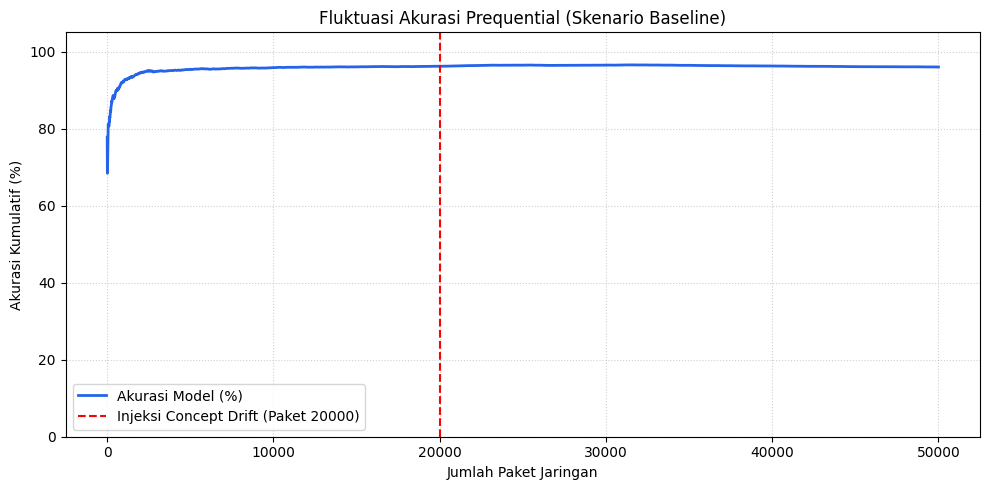

In [5]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from river import compose, preprocessing, tree, ensemble, metrics, stream
import tracemalloc

# 1. MENYIAPKAN ARSITEKTUR LENGKAP
base_model = tree.HoeffdingTreeClassifier()
model = compose.Pipeline(
    preprocessing.MinMaxScaler(),
    ensemble.ADWINBaggingClassifier(model=base_model, n_models=10, seed=42),
)

# 2. MENYIAPKAN 7 METRIK EVALUASI (TAMBAHAN CONFUSION MATRIX)
metric_acc = metrics.Accuracy()
metric_prec = metrics.Precision()
metric_rec = metrics.Recall()
metric_f1 = metrics.F1()
metric_kappa = metrics.CohenKappa()
metric_cm = metrics.ConfusionMatrix()  # <-- Tambahan untuk Tabel 6.1

# Persiapan variabel untuk membuat Grafik (Gambar 6.1)
riwayat_paket = []
riwayat_akurasi = []

file_path = "dataset_final_2juta.csv"  # Pastikan path ini benar
print("🚀 Membaca dataset...")
df_full = pd.read_csv(file_path)

# Mengambil subset 5.000 data agar sesuai skenario Bab 5.3.2
df_subset = df_full.sample(n=50000, random_state=42).reset_index(drop=True)
print(f"✅ Subset data berhasil disiapkan. Total baris: {len(df_subset):,}")

X_data = df_subset.drop(columns=["Label"])
y_data = df_subset["Label"]

waktu_mulai = time.time()
total_diproses = 0

print("🔄 Memulai Proses Incremental Learning (Simulasi 5000 Paket)...")
tracemalloc.start()
for x, y_true in stream.iter_pandas(X_data, y_data):
    total_diproses += 1

    # SIMULASI CONCEPT DRIFT: Mulai paket ke-2000, jika ini paket serangan (1),
    # kita samarkan ukurannya agar AI terkecoh (Mimicry Attack)
    if total_diproses >= 20000 and y_true == 1:
        # 1. Samarkan ukuran paket
        if "IN_BYTES" in x:
            x["IN_BYTES"] = 50
        if "OUT_BYTES" in x:
            x["OUT_BYTES"] = 50

        # 2. PERPARAH SERANGAN: Samarkan ritme waktu (IAT) seolah-olah normal
        # Mengubah semua nilai yang mengandung kata 'IAT' menjadi angka besar (lambat)
        for key in list(x.keys()):
            if "IAT" in key:
                x[key] = 9999.0

    # a. Testing (Prediksi Mandiri)
    y_pred = model.predict_one(x)

    # b. Evaluasi (Pencatatan Skor Metrik)
    if y_pred is not None:
        metric_acc.update(y_true, y_pred)
        metric_prec.update(y_true, y_pred)
        metric_rec.update(y_true, y_pred)
        metric_f1.update(y_true, y_pred)
        metric_kappa.update(y_true, y_pred)
        metric_cm.update(y_true, y_pred)  # <-- Update Matriks Kebingungan

    # c. Training (Pembaruan Model & ADWIN)
    model.learn_one(x, y_true)

    # Simpan riwayat akurasi setiap 10 paket untuk digambar ke grafik
    if total_diproses % 10 == 0:
        riwayat_paket.append(total_diproses)
        # Ambil nilai persentase akurasi saat itu
        akurasi_saat_ini = metric_acc.get() * 100 if metric_acc.get() else 0
        riwayat_akurasi.append(akurasi_saat_ini)

current_ram, peak_ram = tracemalloc.get_traced_memory()
tracemalloc.stop()
# 3. KALKULASI HASIL FINAL
waktu_selesai = time.time()
latensi_final_ms = ((waktu_selesai - waktu_mulai) / total_diproses) * 1000

pemakaian_ram_mb = peak_ram / (1024 * 1024)
print(f"💾 Peak Memory Usage (Incremental) : {pemakaian_ram_mb:.4f} MB")

print("-" * 75)
print("✅ SIMULASI SKENARIO BASELINE SELESAI!")
print("\n=== HASIL CONFUSION MATRIX (Untuk Tabel 6.1) ===")
print(metric_cm)

print("\n=== HASIL 6 METRIK EVALUASI FINAL (Untuk Tabel 6.2) ===")
print(f"1. Accuracy           : {metric_acc.get() * 100:.2f}%")
print(f"2. Precision          : {metric_prec.get() * 100:.2f}%")
print(f"3. Recall             : {metric_rec.get() * 100:.2f}%")
print(f"4. F1-Score           : {metric_f1.get() * 100:.2f}%")
print(f"5. Kappa Statistic    : {metric_kappa.get() * 100:.2f}%")  # Jadikan persen
print(f"6. Detection Latency  : {latensi_final_ms:.4f} ms/paket")

# 4. MENGGAMBAR GRAFIK (Untuk Gambar 6.1)
plt.figure(figsize=(10, 5))
plt.plot(
    riwayat_paket,
    riwayat_akurasi,
    label="Akurasi Model (%)",
    color="#2563eb",
    linewidth=2,
)
plt.axvline(
    x=20000, color="red", linestyle="--", label="Injeksi Concept Drift (Paket 20000)"
)
plt.title("Fluktuasi Akurasi Prequential (Skenario Baseline)")
plt.xlabel("Jumlah Paket Jaringan")
plt.ylabel("Akurasi Kumulatif (%)")
plt.ylim(0, 105)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Model Random Forest

🚀 [RANDOM FOREST] Membaca dataset...
✅ Subset data berhasil disiapkan. Total baris: 50,000
💉 Menyuntikkan Concept Drift (Mimicry Attack) pada paket 20.000 ke atas...
⚖️ Melakukan Normalisasi Skala Data (MinMaxScaler)...
✅ File 'scaler_batch.pkl' berhasil diciptakan dan disimpan!
🧠 Melatih Random Forest pada 20.000 data pertama (Masa Damai)...
✅ Pelatihan selesai dalam 1.10 detik.
✅ File 'model_rf_batch.pkl' berhasil diciptakan dan disimpan!
🔍 Memprediksi seluruh 50.000 aliran data (Termasuk fase krisis)...
---------------------------------------------------------------------------
✅ SIMULASI RANDOM FOREST (BATCH LEARNING) SELESAI!
💾 Peak Memory Usage (Random Forest) : 17.3486 MB

=== HASIL CONFUSION MATRIX (Keseluruhan 50k Data) ===
[[40255   161]
 [  292  9292]]

=== HASIL METRIK EVALUASI FINAL (Untuk Tabel Perbandingan) ===
1. Accuracy           : 99.09%
2. Precision          : 98.30%
3. Recall             : 96.95%
4. F1-Score           : 97.62%
5. Kappa Statistic    : 97.06%
6. Dete

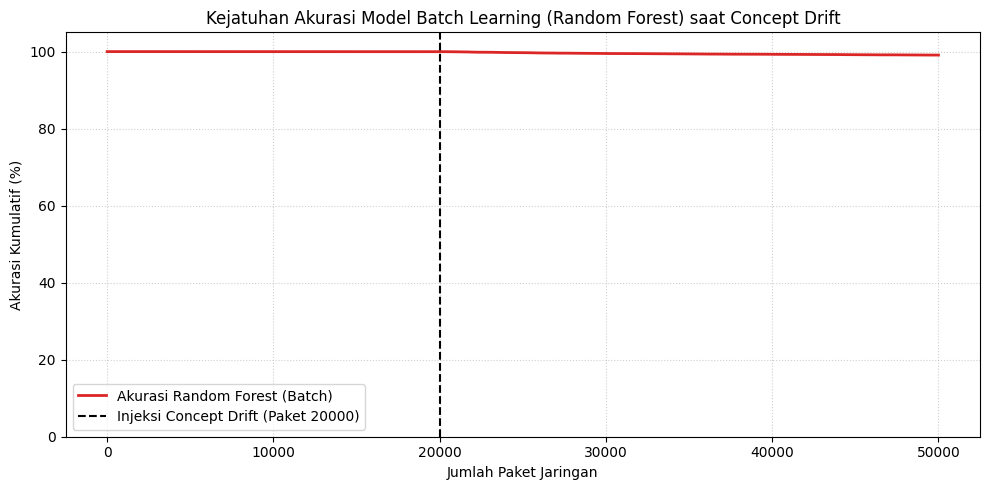

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import tracemalloc
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, cohen_kappa_score, confusion_matrix
)

print("🚀 [RANDOM FOREST] Membaca dataset...")
file_path = "dataset_final_2juta.csv" # Pastikan path ini benar
df_full = pd.read_csv(file_path)

# Mengambil subset 50.000 data (Sama seperti Incremental)
df_subset = df_full.sample(n=50000, random_state=42).reset_index(drop=True)
print(f"✅ Subset data berhasil disiapkan. Total baris: {len(df_subset):,}")

print("💉 Menyuntikkan Concept Drift (Mimicry Attack) pada paket 20.000 ke atas...")
# Kita gunakan vektorisasi Pandas agar jauh lebih cepat daripada looping
mask_serangan = (df_subset.index >= 20000) & (df_subset["Label"] == 1)

# Samarkan ukuran paket
df_subset.loc[mask_serangan, "IN_BYTES"] = 50
df_subset.loc[mask_serangan, "OUT_BYTES"] = 50

# Samarkan ritme waktu (Semua kolom yang mengandung 'IAT')
kolom_iat = [col for col in df_subset.columns if "IAT" in col]
for col in kolom_iat:
    df_subset.loc[mask_serangan, col] = 9999.0

# Pisahkan Fitur (X) dan Target (y)
X_data = df_subset.drop(columns=["Label"])
y_data = df_subset["Label"]

print("⚖️ Melakukan Normalisasi Skala Data (MinMaxScaler)...")
scaler = MinMaxScaler()

X_train_raw = X_data.iloc[:20000]
y_train = y_data.iloc[:20000]

# Fit scaler ("mencetak kacamata") berdasarkan 20.000 data Masa Damai
scaler.fit(X_train_raw)

# Simpan kacamata ini agar bisa dipakai oleh Gateway!
joblib.dump(scaler, "scaler_batch.pkl")
print("✅ File 'scaler_batch.pkl' berhasil diciptakan dan disimpan!")

# Transformasikan data agar sesuai dengan skala 0.0 - 1.0
X_train_scaled = scaler.transform(X_train_raw)
X_data_scaled = scaler.transform(X_data)

# =================================================================
# 2. FASE PELATIHAN (BATCH LEARNING: HANYA MENGGUNAKAN 20.000 DATA AWAL)
# =================================================================
print("🧠 Melatih Random Forest pada 20.000 data pertama (Masa Damai)...")
tracemalloc.start()
# Menggunakan 100 pohon keputusan, n_jobs=-1 agar menggunakan semua core CPU
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

waktu_mulai_train = time.time()
rf_model.fit(X_train_scaled, y_train)
waktu_selesai_train = time.time()
print(f"✅ Pelatihan selesai dalam {waktu_selesai_train - waktu_mulai_train:.2f} detik.")

joblib.dump(rf_model, "model_rf_batch.pkl")
print("✅ File 'model_rf_batch.pkl' berhasil diciptakan dan disimpan!")
# =================================================================
# 3. FASE EVALUASI & PREDIKSI (MENSIMULASIKAN PREQUENTIAL)
# =================================================================
print("🔍 Memprediksi seluruh 50.000 aliran data (Termasuk fase krisis)...")

waktu_mulai_pred = time.time()
# Model memprediksi semuanya sekaligus (sifat asli Batch Learning)
y_pred_all = rf_model.predict(X_data_scaled)
waktu_selesai_pred = time.time()

current_ram, peak_ram = tracemalloc.get_traced_memory()
tracemalloc.stop()

latensi_final_ms = ((waktu_selesai_pred - waktu_mulai_pred) / len(X_data)) * 1000

# Kalkulasi array untuk grafik (Meniru gaya perhitungan Incremental)
riwayat_paket_rf = []
riwayat_akurasi_rf = []
benar_kumulatif = 0

for i in range(len(y_pred_all)):
    if y_pred_all[i] == y_data.iloc[i]:
        benar_kumulatif += 1
        
    total_diproses = i + 1
    
    # Catat akurasi setiap 10 paket
    if total_diproses % 10 == 0:
        riwayat_paket_rf.append(total_diproses)
        riwayat_akurasi_rf.append((benar_kumulatif / total_diproses) * 100)

# =================================================================
# 4. HASIL FINAL & VISUALISASI
# =================================================================
print("-" * 75)
print("✅ SIMULASI RANDOM FOREST (BATCH LEARNING) SELESAI!")
pemakaian_ram_mb = peak_ram / (1024 * 1024)
print(f"💾 Peak Memory Usage (Random Forest) : {pemakaian_ram_mb:.4f} MB")
print("\n=== HASIL CONFUSION MATRIX (Keseluruhan 50k Data) ===")
print(confusion_matrix(y_data, y_pred_all))

print("\n=== HASIL METRIK EVALUASI FINAL (Untuk Tabel Perbandingan) ===")
print(f"1. Accuracy           : {accuracy_score(y_data, y_pred_all) * 100:.2f}%")
print(f"2. Precision          : {precision_score(y_data, y_pred_all) * 100:.2f}%")
print(f"3. Recall             : {recall_score(y_data, y_pred_all) * 100:.2f}%")
print(f"4. F1-Score           : {f1_score(y_data, y_pred_all) * 100:.2f}%")
print(f"5. Kappa Statistic    : {cohen_kappa_score(y_data, y_pred_all) * 100:.2f}%")
print(f"6. Detection Latency  : {latensi_final_ms:.4f} ms/paket")

# Menggambar Grafik Random Forest
plt.figure(figsize=(10, 5))
plt.plot(
    riwayat_paket_rf,
    riwayat_akurasi_rf,
    label="Akurasi Random Forest (Batch)",
    color="#dc2626", # Warna Merah untuk RF
    linewidth=2,
    linestyle="-"
)
plt.axvline(
    x=20000, color="black", linestyle="--", label="Injeksi Concept Drift (Paket 20000)"
)
plt.title("Kejatuhan Akurasi Model Batch Learning (Random Forest) saat Concept Drift")
plt.xlabel("Jumlah Paket Jaringan")
plt.ylabel("Akurasi Kumulatif (%)")
plt.ylim(0, 105)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Model Deep Learning

🚀 [DEEP LEARNING] Membaca dataset...
✅ Subset data berhasil disiapkan. Total baris: 50,000
💉 Menyuntikkan Concept Drift (Mimicry Attack) pada paket 20.000 ke atas...
⚖️ Melakukan Normalisasi Skala Data (MinMaxScaler)...
✅ File 'scaler_batch.pkl' berhasil diciptakan dan disimpan!
🧠 Membangun arsitektur Jaringan Saraf Tiruan (Deep Learning)...
⏳ Melatih Deep Learning pada 20.000 data pertama...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9488 - loss: 0.1605
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9765 - loss: 0.0629
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9790 - loss: 0.0540
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9817 - loss: 0.0480
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9855 - loss: 0.0420
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9865 - loss: 0.0383
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9866 - loss: 0.0369
Ep

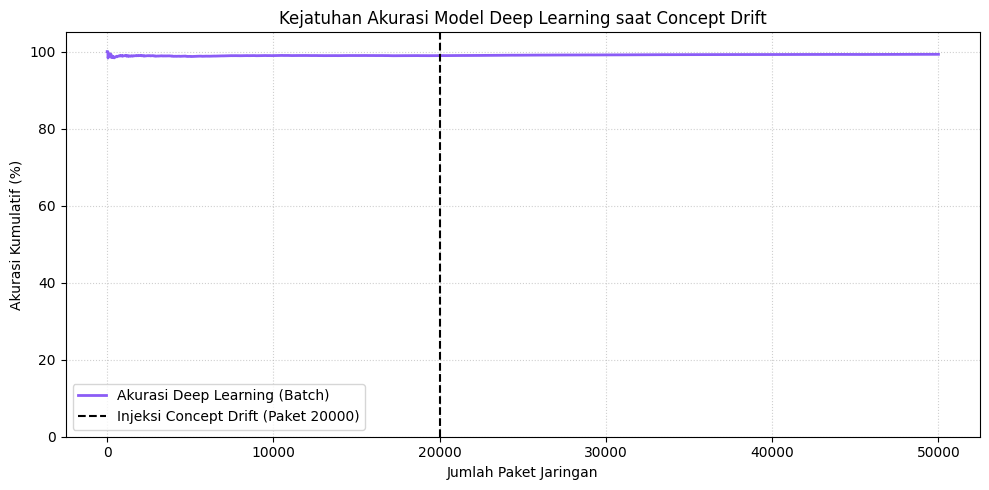

In [4]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, cohen_kappa_score, confusion_matrix
)
import tracemalloc
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input

print("🚀 [DEEP LEARNING] Membaca dataset...")
file_path = "dataset_final_2juta.csv" # Pastikan path ini benar
df_full = pd.read_csv(file_path)

# Mengambil subset 50.000 data
df_subset = df_full.sample(n=50000, random_state=42).reset_index(drop=True)
print(f"✅ Subset data berhasil disiapkan. Total baris: {len(df_subset):,}")

# =================================================================
# 1. INJEKSI CONCEPT DRIFT (MIMICRY ATTACK)
# =================================================================
print("💉 Menyuntikkan Concept Drift (Mimicry Attack) pada paket 20.000 ke atas...")

mask_serangan = (df_subset.index >= 20000) & (df_subset["Label"] == 1)

# Samarkan ukuran paket
df_subset.loc[mask_serangan, "IN_BYTES"] = 50
df_subset.loc[mask_serangan, "OUT_BYTES"] = 50

# Samarkan ritme waktu
kolom_iat = [col for col in df_subset.columns if "IAT" in col]
for col in kolom_iat:
    df_subset.loc[mask_serangan, col] = 9999.0

X_data = df_subset.drop(columns=["Label"])
y_data = df_subset["Label"]

# =================================================================
# 2. NORMALISASI FITUR (WAJIB UNTUK DEEP LEARNING) & SPLITTING
# =================================================================
print("⚖️ Melakukan Normalisasi Skala Data (MinMaxScaler)...")
scaler = MinMaxScaler()

# Ambil 20.000 data awal untuk Masa Damai (Fase Training)
X_train_raw = X_data.iloc[:20000]
y_train = y_data.iloc[:20000]

# Fit scaler HANYA pada data training agar tidak ada kebocoran data (data leakage)
scaler.fit(X_train_raw)

joblib.dump(scaler, "scaler_batch.pkl")
print("✅ File 'scaler_batch.pkl' berhasil diciptakan dan disimpan!")

# Transformasikan semua data menggunakan aturan dari data training
X_train_scaled = scaler.transform(X_train_raw)
X_all_scaled = scaler.transform(X_data) # Seluruh 50.000 data untuk dievaluasi nanti

# =================================================================
# 3. MEMBANGUN ARSITEKTUR DEEP NEURAL NETWORK (DNN)
# =================================================================
print("🧠 Membangun arsitektur Jaringan Saraf Tiruan (Deep Learning)...")
dimensi_input = X_train_scaled.shape[1]

dnn_model = Sequential([
    Input(shape=(dimensi_input,)),
    Dense(64, activation='relu'),   # Hidden Layer 1
    Dense(32, activation='relu'),   # Hidden Layer 2
    Dense(16, activation='relu'),   # Hidden Layer 3
    Dense(1, activation='sigmoid')  # Output Layer (0 atau 1)
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# =================================================================
# 4. FASE PELATIHAN (BATCH LEARNING: 20.000 DATA)
# =================================================================
print("⏳ Melatih Deep Learning pada 20.000 data pertama...")
tracemalloc.start()
waktu_mulai_train = time.time()

# Melatih model selama 10 Epoch (putaran)
history = dnn_model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, verbose=1)

waktu_selesai_train = time.time()
print(f"✅ Pelatihan selesai dalam {waktu_selesai_train - waktu_mulai_train:.2f} detik.")

dnn_model.save("model_dnn_batch.keras")
print("✅ File 'model_dnn_batch.keras' berhasil diciptakan dan disimpan!")

# =================================================================
# 5. FASE EVALUASI & PREDIKSI (MENSIMULASIKAN PREQUENTIAL)
# =================================================================
print("🔍 Memprediksi seluruh 50.000 aliran data (Termasuk fase krisis)...")

waktu_mulai_pred = time.time()
# DNN mengeluarkan nilai probabilitas (0.0 - 1.0), kita harus ubah ke kelas 0 atau 1
y_pred_prob = dnn_model.predict(X_all_scaled, verbose=0)
y_pred_all = (y_pred_prob > 0.5).astype(int).flatten()
waktu_selesai_pred = time.time()

current_ram, peak_ram = tracemalloc.get_traced_memory()
tracemalloc.stop()

latensi_final_ms = ((waktu_selesai_pred - waktu_mulai_pred) / len(X_data)) * 1000

# Kalkulasi array untuk grafik
riwayat_paket_dnn = []
riwayat_akurasi_dnn = []
benar_kumulatif = 0

for i in range(len(y_pred_all)):
    if y_pred_all[i] == y_data.iloc[i]:
        benar_kumulatif += 1
        
    total_diproses = i + 1
    
    # Catat akurasi setiap 10 paket
    if total_diproses % 10 == 0:
        riwayat_paket_dnn.append(total_diproses)
        riwayat_akurasi_dnn.append((benar_kumulatif / total_diproses) * 100)

# =================================================================
# 6. HASIL FINAL & VISUALISASI
# =================================================================
print("-" * 75)
print("✅ SIMULASI DEEP LEARNING (BATCH LEARNING) SELESAI!")
pemakaian_ram_mb = peak_ram / (1024 * 1024)
print(f"💾 Peak Memory Usage (Deep Learning) : {pemakaian_ram_mb:.4f} MB")
print("\n=== HASIL CONFUSION MATRIX (Keseluruhan 50k Data) ===")
print(confusion_matrix(y_data, y_pred_all))

print("\n=== HASIL METRIK EVALUASI FINAL (Untuk Tabel Perbandingan) ===")
print(f"1. Accuracy           : {accuracy_score(y_data, y_pred_all) * 100:.2f}%")
print(f"2. Precision          : {precision_score(y_data, y_pred_all) * 100:.2f}%")
print(f"3. Recall             : {recall_score(y_data, y_pred_all) * 100:.2f}%")
print(f"4. F1-Score           : {f1_score(y_data, y_pred_all) * 100:.2f}%")
print(f"5. Kappa Statistic    : {cohen_kappa_score(y_data, y_pred_all) * 100:.2f}%")
print(f"6. Detection Latency  : {latensi_final_ms:.4f} ms/paket")

# Menggambar Grafik Deep Learning
plt.figure(figsize=(10, 5))
plt.plot(
    riwayat_paket_dnn,
    riwayat_akurasi_dnn,
    label="Akurasi Deep Learning (Batch)",
    color="#8b5cf6", # Warna Ungu untuk DNN
    linewidth=2,
    linestyle="-"
)
plt.axvline(
    x=20000, color="black", linestyle="--", label="Injeksi Concept Drift (Paket 20000)"
)
plt.title("Kejatuhan Akurasi Model Deep Learning saat Concept Drift")
plt.xlabel("Jumlah Paket Jaringan")
plt.ylabel("Akurasi Kumulatif (%)")
plt.ylim(0, 105)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from river import compose, preprocessing, tree, ensemble, metrics, stream

# 1. MENYIAPKAN ARSITEKTUR LENGKAP
base_model = tree.HoeffdingTreeClassifier()
model = compose.Pipeline(
    preprocessing.MinMaxScaler(),
    ensemble.ADWINBaggingClassifier(model=base_model, n_models=10, seed=42),
)

# 2. MENYIAPKAN 7 METRIK EVALUASI (TAMBAHAN CONFUSION MATRIX)
metric_acc = metrics.Accuracy()
metric_prec = metrics.Precision()
metric_rec = metrics.Recall()
metric_f1 = metrics.F1()
metric_kappa = metrics.CohenKappa()
metric_cm = metrics.ConfusionMatrix()  # <-- Tambahan untuk Tabel 6.1

# Persiapan variabel untuk membuat Grafik (Gambar 6.1)
riwayat_paket = []
riwayat_akurasi = []

file_path = "dataset_final_2juta.csv"  # Pastikan path ini benar
print("🚀 Membaca dataset...")
df_full = pd.read_csv(file_path)

# Mengambil subset 5.000 data agar sesuai skenario Bab 5.3.2
df_subset = df_full.sample(n=50000, random_state=42).reset_index(drop=True)
print(f"✅ Subset data berhasil disiapkan. Total baris: {len(df_subset):,}")

X_data = df_subset.drop(columns=["Label"])
y_data = df_subset["Label"]

# Cari semua kolom yang ada kata 'IAT'
kolom_iat = [col for col in X_data.columns if 'IAT' in col]
# Buang kolom IAT tersebut dari data secara paksa
X_data = X_data.drop(columns=kolom_iat)
print(f"🔪 Skenario Ablasi: Membuang {len(kolom_iat)} fitur temporal (IAT)!")

waktu_mulai = time.time()
total_diproses = 0

print("🔄 Memulai Proses Incremental Learning (Simulasi 5000 Paket)...")
for x, y_true in stream.iter_pandas(X_data, y_data):
    total_diproses += 1

    # SIMULASI CONCEPT DRIFT: Mulai paket ke-2000, jika ini paket serangan (1),
    # kita samarkan ukurannya agar AI terkecoh (Mimicry Attack)
    if total_diproses >= 20000 and y_true == 1:
        # 1. Samarkan ukuran paket
        if "IN_BYTES" in x:
            x["IN_BYTES"] = 50
        if "OUT_BYTES" in x:
            x["OUT_BYTES"] = 50

        # 2. PERPARAH SERANGAN: Samarkan ritme waktu (IAT) seolah-olah normal
        # Mengubah semua nilai yang mengandung kata 'IAT' menjadi angka besar (lambat)
        for key in list(x.keys()):
            if "IAT" in key:
                x[key] = 9999.0

    # a. Testing (Prediksi Mandiri)
    y_pred = model.predict_one(x)

    # b. Evaluasi (Pencatatan Skor Metrik)
    if y_pred is not None:
        metric_acc.update(y_true, y_pred)
        metric_prec.update(y_true, y_pred)
        metric_rec.update(y_true, y_pred)
        metric_f1.update(y_true, y_pred)
        metric_kappa.update(y_true, y_pred)
        metric_cm.update(y_true, y_pred)  # <-- Update Matriks Kebingungan

    # c. Training (Pembaruan Model & ADWIN)
    model.learn_one(x, y_true)

    # Simpan riwayat akurasi setiap 10 paket untuk digambar ke grafik
    if total_diproses % 10 == 0:
        riwayat_paket.append(total_diproses)
        # Ambil nilai persentase akurasi saat itu
        akurasi_saat_ini = metric_acc.get() * 100 if metric_acc.get() else 0
        riwayat_akurasi.append(akurasi_saat_ini)

# 3. KALKULASI HASIL FINAL
waktu_selesai = time.time()
latensi_final_ms = ((waktu_selesai - waktu_mulai) / total_diproses) * 1000

print("-" * 75)
print("✅ SIMULASI SKENARIO BASELINE SELESAI!")
print("\n=== HASIL CONFUSION MATRIX (Untuk Tabel 6.1) ===")
print(metric_cm)

print("\n=== HASIL 6 METRIK EVALUASI FINAL (Untuk Tabel 6.2) ===")
print(f"1. Accuracy           : {metric_acc.get() * 100:.2f}%")
print(f"2. Precision          : {metric_prec.get() * 100:.2f}%")
print(f"3. Recall             : {metric_rec.get() * 100:.2f}%")
print(f"4. F1-Score           : {metric_f1.get() * 100:.2f}%")
print(f"5. Kappa Statistic    : {metric_kappa.get() * 100:.2f}%")  # Jadikan persen
print(f"6. Detection Latency  : {latensi_final_ms:.4f} ms/paket")

# 4. MENGGAMBAR GRAFIK (Untuk Gambar 6.1)
plt.figure(figsize=(10, 5))
plt.plot(
    riwayat_paket,
    riwayat_akurasi,
    label="Akurasi Model (%)",
    color="#2563eb",
    linewidth=2,
)
plt.axvline(
    x=20000, color="red", linestyle="--", label="Injeksi Concept Drift (Paket 20000)"
)
plt.title("Fluktuasi Akurasi Prequential (Skenario Baseline)")
plt.xlabel("Jumlah Paket Jaringan")
plt.ylabel("Akurasi Kumulatif (%)")
plt.ylim(0, 105)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

🚀 Membaca dataset...
✅ Subset data berhasil disiapkan. Total baris: 50,000
🔪 Skenario Ablasi: Membuang 8 fitur temporal (IAT)!
🔄 Memulai Proses Incremental Learning (Simulasi 5000 Paket)...


KeyboardInterrupt: 

🚀 Membaca dataset...
✅ Subset data berhasil disiapkan. Total baris: 50,000
🔄 Memulai Proses Incremental Learning (Simulasi 5000 Paket)...
---------------------------------------------------------------------------
✅ SIMULASI SKENARIO BASELINE SELESAI!

=== HASIL CONFUSION MATRIX (Untuk Tabel 6.1) ===
    0        1      
0   39,399   1,016  
1      783   8,801  

=== HASIL 6 METRIK EVALUASI FINAL (Untuk Tabel 6.2) ===
1. Accuracy           : 96.40%
2. Precision          : 89.65%
3. Recall             : 91.83%
4. F1-Score           : 90.73%
5. Kappa Statistic    : 88.50%
6. Detection Latency  : 18.0102 ms/paket


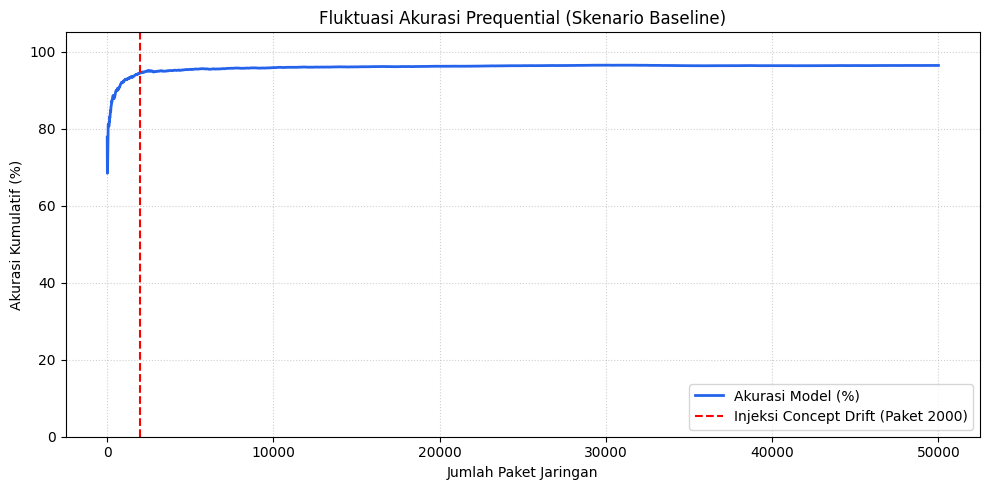

In [ ]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from river import compose, preprocessing, tree, ensemble, metrics, stream

# 1. MENYIAPKAN ARSITEKTUR LENGKAP
base_model = tree.HoeffdingTreeClassifier()
model = compose.Pipeline(
    preprocessing.MinMaxScaler(),
    ensemble.ADWINBaggingClassifier(model=base_model, n_models=10, seed=42),
)

# 2. MENYIAPKAN 7 METRIK EVALUASI (TAMBAHAN CONFUSION MATRIX)
metric_acc = metrics.Accuracy()
metric_prec = metrics.Precision()
metric_rec = metrics.Recall()
metric_f1 = metrics.F1()
metric_kappa = metrics.CohenKappa()
metric_cm = metrics.ConfusionMatrix()  # <-- Tambahan untuk Tabel 6.1

# Persiapan variabel untuk membuat Grafik (Gambar 6.1)
riwayat_paket = []
riwayat_akurasi = []

file_path = "dataset_final_2juta.csv"  # Pastikan path ini benar
print("🚀 Membaca dataset...")
df_full = pd.read_csv(file_path)

# Mengambil subset 5.000 data agar sesuai skenario Bab 5.3.2
df_subset = df_full.sample(n=50000, random_state=42).reset_index(drop=True)
print(f"✅ Subset data berhasil disiapkan. Total baris: {len(df_subset):,}")

X_data = df_subset.drop(columns=["Label"])
y_data = df_subset["Label"]

waktu_mulai = time.time()
total_diproses = 0

print("🔄 Memulai Proses Incremental Learning (Simulasi 5000 Paket)...")
for x, y_true in stream.iter_pandas(X_data, y_data):
    total_diproses += 1

    # SIMULASI CONCEPT DRIFT: Mulai paket ke-2000, jika ini paket serangan (1),
    # kita samarkan ukurannya agar AI terkecoh (Mimicry Attack)
    if total_diproses >= 20000 and y_true == 1:
        # 1. Samarkan ukuran paket
        if "IN_BYTES" in x:
            x["IN_BYTES"] = 50
        if "OUT_BYTES" in x:
            x["OUT_BYTES"] = 50

        # 2. PERPARAH SERANGAN: Samarkan ritme waktu (IAT) seolah-olah normal
        # Mengubah semua nilai yang mengandung kata 'IAT' menjadi angka besar (lambat)
        for key in list(x.keys()):
            if "IAT" in key:
                x[key] = 9999.0

    # a. Testing (Prediksi Mandiri)
    y_pred = model.predict_one(x)

    # b. Evaluasi (Pencatatan Skor Metrik)
    if y_pred is not None:
        metric_acc.update(y_true, y_pred)
        metric_prec.update(y_true, y_pred)
        metric_rec.update(y_true, y_pred)
        metric_f1.update(y_true, y_pred)
        metric_kappa.update(y_true, y_pred)
        metric_cm.update(y_true, y_pred)  # <-- Update Matriks Kebingungan

    # c. Training (Pembaruan Model & ADWIN)
    model.learn_one(x, y_true)

    # Simpan riwayat akurasi setiap 10 paket untuk digambar ke grafik
    if total_diproses % 10 == 0:
        riwayat_paket.append(total_diproses)
        # Ambil nilai persentase akurasi saat itu
        akurasi_saat_ini = metric_acc.get() * 100 if metric_acc.get() else 0
        riwayat_akurasi.append(akurasi_saat_ini)

# 3. KALKULASI HASIL FINAL
waktu_selesai = time.time()
latensi_final_ms = ((waktu_selesai - waktu_mulai) / total_diproses) * 1000

print("-" * 75)
print("✅ SIMULASI SKENARIO BASELINE SELESAI!")
print("\n=== HASIL CONFUSION MATRIX (Untuk Tabel 6.1) ===")
print(metric_cm)

print("\n=== HASIL 6 METRIK EVALUASI FINAL (Untuk Tabel 6.2) ===")
print(f"1. Accuracy           : {metric_acc.get() * 100:.2f}%")
print(f"2. Precision          : {metric_prec.get() * 100:.2f}%")
print(f"3. Recall             : {metric_rec.get() * 100:.2f}%")
print(f"4. F1-Score           : {metric_f1.get() * 100:.2f}%")
print(f"5. Kappa Statistic    : {metric_kappa.get() * 100:.2f}%")  # Jadikan persen
print(f"6. Detection Latency  : {latensi_final_ms:.4f} ms/paket")

# 4. MENGGAMBAR GRAFIK (Untuk Gambar 6.1)
plt.figure(figsize=(10, 5))
plt.plot(
    riwayat_paket,
    riwayat_akurasi,
    label="Akurasi Model (%)",
    color="#2563eb",
    linewidth=2,
)
plt.axvline(
    x=20000, color="red", linestyle="--", label="Injeksi Concept Drift (Paket 20000)"
)
plt.title("Fluktuasi Akurasi Prequential (Skenario Baseline)")
plt.xlabel("Jumlah Paket Jaringan")
plt.ylabel("Akurasi Kumulatif (%)")
plt.ylim(0, 105)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

file_asli = 'dataset_fdi_bersih.csv'
file_mini = 'dataset_dev_2juta.csv'

print("Membaca 17,1 juta data ke RAM... (Tunggu sekitar 1-2 menit)")
df_full = pd.read_csv(file_asli, engine='c')

print("Memotong data dari baris ke-8.000.000 sampai 10.000.000...")
df_mini = df_full.iloc[8000000:10000000]

print(f"Menyimpan ke {file_mini}...")
df_mini.to_csv(file_mini, index=False)

print("Selesai! Sekarang Anda punya dataset ringan untuk uji coba cepat.")

Membaca 17,1 juta data ke RAM... (Tunggu sekitar 1-2 menit)
Memotong data dari baris ke-8.000.000 sampai 10.000.000...
Menyimpan ke dataset_dev_2juta.csv...
Selesai! Sekarang Anda punya dataset ringan untuk uji coba cepat.


In [3]:
import pandas as pd

# Membaca dataset mini yang baru dibuat
df_mini = pd.read_csv('dataset_dev_2juta.csv', usecols=['Label'])

print("=== DISTRIBUSI DATA DI DATASET MINI (2 JUTA) ===")
# Menghitung jumlah Normal (0) dan Serangan (1)
distribusi = df_mini['Label'].value_counts()
print(distribusi)

# Menampilkan persentase
persentase = df_mini['Label'].value_counts(normalize=True) * 100
print("\nPersentase:")
print(persentase)

=== DISTRIBUSI DATA DI DATASET MINI (2 JUTA) ===
Label
0    1618223
1     381777
Name: count, dtype: int64

Persentase:
Label
0    80.91115
1    19.08885
Name: proportion, dtype: float64


In [2]:
import pandas as pd

print("⏳ Membaca dataset dev 2 juta baris...")
# Ganti path jika file berada di folder lain
df_raw = pd.read_csv('dataset_dev_2juta.csv')

print("🧹 Membuang kolom identifier waktu (FLOW_START & FLOW_END)...")
df_clean = df_raw.drop(columns=['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS'])

print(f"✅ Sisa kolom saat ini: {len(df_clean.columns)} kolom.")

print("💾 Menyimpan dataset final... (Mohon tunggu sebentar)")
# index=False sangat penting agar Pandas tidak membuat kolom nomor urut baru
df_clean.to_csv('dataset_final_2juta.csv', index=False)

print("🎉 SELESAI! File 'dataset_final_2juta.csv' siap digunakan untuk training dan simulasi.")

⏳ Membaca dataset dev 2 juta baris...
🧹 Membuang kolom identifier waktu (FLOW_START & FLOW_END)...
✅ Sisa kolom saat ini: 50 kolom.
💾 Menyimpan dataset final... (Mohon tunggu sebentar)
🎉 SELESAI! File 'dataset_final_2juta.csv' siap digunakan untuk training dan simulasi.


In [3]:
import pandas as pd

print("⏳ Membaca dataset dev 2 juta baris...")
# Ganti path jika file berada di folder lain
df_raw = pd.read_csv('dataset_fdi_bersih.csv')

print("🧹 Membuang kolom identifier waktu (FLOW_START & FLOW_END)...")
df_clean = df_raw.drop(columns=['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS'])

print(f"✅ Sisa kolom saat ini: {len(df_clean.columns)} kolom.")

print("💾 Menyimpan dataset final... (Mohon tunggu sebentar)")
# index=False sangat penting agar Pandas tidak membuat kolom nomor urut baru
df_clean.to_csv('dataset_final_bersih.csv', index=False)

print("🎉 SELESAI! File 'dataset_final_2juta.csv' siap digunakan untuk training dan simulasi.")

⏳ Membaca dataset dev 2 juta baris...
🧹 Membuang kolom identifier waktu (FLOW_START & FLOW_END)...
✅ Sisa kolom saat ini: 50 kolom.
💾 Menyimpan dataset final... (Mohon tunggu sebentar)
🎉 SELESAI! File 'dataset_final_2juta.csv' siap digunakan untuk training dan simulasi.
